In [1]:
import scipy.io, tifffile, numpy as np, pandas as pd, os, sys
from skimage import measure

if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']
sys.path.append('../src')
from preprocessing import preprocess_image

DELTA_PATH   = '../data/raw/delta/tests/data/movie_mothermachine_tif'
MAT_DIR      = os.path.join(DELTA_PATH, 'expected_results')
TIF_TEMPLATE = os.path.join(DELTA_PATH, 'Position{p:02d}Channel{c:02d}Frames{t:06d}.tif')

PATCH_SIZE = 64
patches, labels, meta = [], [], []

# ── Cache all TIF files upfront ──────────────────────────
print("Caching TIF files...")
img_cache = {}
tif_files = [f for f in os.listdir(DELTA_PATH) if f.endswith('.tif')]
for i, fname in enumerate(sorted(tif_files)):
    path = os.path.join(DELTA_PATH, fname)
    img_cache[fname] = preprocess_image(tifffile.imread(path))
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(tif_files)}")
print(f"Cached {len(img_cache)} images")

# ── Extract ALL frames per cell ──────────────────────────
print("\nExtracting patches (all frames per cell)...")

for mat_file in sorted(os.listdir(MAT_DIR)):
    if not mat_file.endswith('.mat'):
        continue
    pos_idx = int(mat_file.replace('Position', '').replace('.mat', ''))
    print(f"Processing {mat_file}...")

    mat = scipy.io.loadmat(
        os.path.join(MAT_DIR, mat_file), simplify_cells=False
    )
    res = mat['res']

    for ch_idx in range(res.shape[1]):
        chamber     = res[0, ch_idx]
        labelsstack = chamber['labelsstack'][0, 0]
        lineage_arr = chamber['lineage'][0, 0]
        if lineage_arr.size == 0:
            continue

        n_cells  = lineage_arr.shape[1]
        n_frames = labelsstack.shape[0]

        # Build frame lookup from cache
        imgs = {}
        for t in range(1, n_frames + 1):
            fname = f'Position{pos_idx+1:02d}Channel01Frames{t:06d}.tif'
            if fname in img_cache:
                imgs[t] = img_cache[fname]

        if len(imgs) == 0:
            continue

        for cell_idx in range(n_cells):
            cell = lineage_arr[0, cell_idx]
            try:
                frames    = cell['frames'][0, 0][0].astype(int)
                daughters = cell['daughters'][0, 0][0]
                divided   = int(np.any(daughters > 0))
            except Exception:
                continue

            # ── ALL frames per cell (changed from middle frame only) ──
            for frame_num in frames:
                if frame_num not in imgs:
                    continue
                img = imgs[frame_num]

                mask_frame = labelsstack[frame_num - 1]
                cell_mask  = (mask_frame == cell_idx + 1)

                if not cell_mask.any():
                    continue

                props = measure.regionprops(cell_mask.astype(int))
                if len(props) == 0:
                    continue

                cy = int(props[0].centroid[0])
                cx = int(props[0].centroid[1])
                half = PATCH_SIZE // 2

                r0 = max(0, cy - half); r1 = min(img.shape[0], cy + half)
                c0 = max(0, cx - half); c1 = min(img.shape[1], cx + half)
                patch = img[r0:r1, c0:c1]

                if patch.shape != (PATCH_SIZE, PATCH_SIZE):
                    padded = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
                    padded[:patch.shape[0], :patch.shape[1]] = patch
                    patch = padded

                patches.append(patch.astype(np.float32))
                labels.append(divided)
                meta.append({
                    'mat_file'  : mat_file,
                    'chamber'   : ch_idx,
                    'cell_id'   : cell_idx,
                    'frame'     : int(frame_num),
                    'divided'   : divided
                })

patches = np.array(patches)
labels  = np.array(labels)

print(f"\nExpanded patches: {patches.shape}")
print(f"Arrested (0): {(labels==0).sum()}")
print(f"Divided  (1): {(labels==1).sum()}")
print(f"Increase from 126: {len(labels) - 126}x more patches")

os.makedirs('../data/features', exist_ok=True)
np.save('../data/features/cell_patches_allframes.npy', patches)
np.save('../data/features/cell_labels_allframes.npy', labels)
pd.DataFrame(meta).to_csv('../data/features/patch_meta_allframes.csv', index=False)
print("Saved.")

Caching TIF files...
  10/40
  20/40
  30/40
  40/40
Cached 40 images

Extracting patches (all frames per cell)...
Processing Position000001.mat...
Processing Position000002.mat...

Expanded patches: (750, 64, 64)
Arrested (0): 214
Divided  (1): 536
Increase from 126: 624x more patches
Saved.


In [2]:
import os

for species in ['ecoli', 'bsubtilis', 'staph']:
    base = f'../data/raw/deepbacs/{species}'
    print(f"\n{species.upper()}:")
    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        if level <= 2:
            tifs = [f for f in files if f.endswith('.tif')]
            pngs = [f for f in files if f.endswith('.png')]
            if tifs or pngs:
                rel = root.replace(base, '')
                print(f"  {rel or '/'}: {len(tifs)} tif, {len(pngs)} png")


ECOLI:
  \live-cell_data\time_series_raw: 10 tif, 0 png
  \live-cell_data\time_series_scaled: 10 tif, 0 png
  \test\brightfield: 15 tif, 0 png
  \test\masks_binary: 15 tif, 0 png
  \test\masks_RoiMap: 15 tif, 0 png
  \train\brightfield: 19 tif, 0 png
  \train\masks_binary: 19 tif, 0 png
  \train\masks_RoiMap: 19 tif, 0 png

BSUBTILIS:

STAPH:


In [3]:
import os

# Check exact folder names
print(os.listdir('../data/raw/deepbacs/'))

# Then check bsubtilis structure
for species_dir in os.listdir('../data/raw/deepbacs/'):
    base = f'../data/raw/deepbacs/{species_dir}'
    print(f"\n{species_dir.upper()}:")
    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        if level <= 3:
            tifs = [f for f in files if f.endswith('.tif')]
            pngs = [f for f in files if f.endswith('.png')]
            if tifs or pngs:
                rel = root.replace(base, '')
                print(f"  {rel or '/'}: {len(tifs)} tif, {len(pngs)} png")

['bsubtilis', 'ecoli', 'staph']

BSUBTILIS:
  \CARE_U-Net_dataset\test\fluorescence: 10 tif, 0 png
  \CARE_U-Net_dataset\test\masks: 10 tif, 0 png
  \CARE_U-Net_dataset\train\fluorescence: 80 tif, 0 png
  \CARE_U-Net_dataset\train\masks: 80 tif, 0 png
  \pix2pix_dataset\test\fluorescence: 0 tif, 10 png
  \pix2pix_dataset\test\masks: 0 tif, 10 png
  \pix2pix_dataset\train\fluorescence: 0 tif, 80 png
  \pix2pix_dataset\train\masks: 0 tif, 80 png
  \SplineDist_dataset\test\fluorescence: 10 tif, 0 png
  \SplineDist_dataset\test\masks: 10 tif, 0 png
  \SplineDist_dataset\train\fluorescence: 32 tif, 0 png
  \SplineDist_dataset\train\masks: 32 tif, 0 png
  \StarDist_dataset\test\fluorescence: 10 tif, 0 png
  \StarDist_dataset\test\masks: 10 tif, 0 png

ECOLI:
  \live-cell_data\time_series_raw: 10 tif, 0 png
  \live-cell_data\time_series_scaled: 10 tif, 0 png
  \test\brightfield: 15 tif, 0 png
  \test\masks_binary: 15 tif, 0 png
  \test\masks_RoiMap: 15 tif, 0 png
  \train\brightfield: 19 tif,

In [5]:
import numpy as np, pandas as pd
from skimage import measure
import tifffile, os, sys

if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']
sys.path.append('../src')
from preprocessing import preprocess_image

def extract_features_deepbacs(img_dir, mask_dir, species_name, max_images=20):
    rows = []
    img_files = sorted([f for f in os.listdir(img_dir)
                        if f.endswith('.tif') or f.endswith('.png')])[:max_images]
    
    matched = 0
    for img_file in img_files:
        img_path  = os.path.join(img_dir, img_file)
        mask_path = os.path.join(mask_dir, img_file)
        
        if not os.path.exists(mask_path):
            continue
        
        try:
            raw  = tifffile.imread(img_path)
            mask = tifffile.imread(mask_path)
        except Exception as e:
            print(f"  Skip {img_file}: {e}")
            continue
        
        # Handle multichannel images
        if raw.ndim == 3:
            raw = raw[0] if raw.shape[0] < raw.shape[-1] else raw[:, :, 0]
        if mask.ndim == 3:
            mask = mask[0] if mask.shape[0] < mask.shape[-1] else mask[:, :, 0]
        
        img = preprocess_image(raw.astype(np.float32))
        
        cell_labels = np.unique(mask)
        cell_labels = cell_labels[cell_labels > 0]
        
        if len(cell_labels) == 0:
            continue
        
        matched += 1
        for lbl in cell_labels:
            cell_mask = (mask == lbl)
            if cell_mask.sum() < 10:
                continue
            
            cell_pixels = img[cell_mask]
            props_list  = measure.regionprops(cell_mask.astype(int))
            if len(props_list) == 0:
                continue
            p = props_list[0]
            
            minr, minc, maxr, maxc = p.bbox
            mid_row  = (minr + maxr) // 2
            top_mask = cell_mask.copy(); top_mask[mid_row:, :] = False
            bot_mask = cell_mask.copy(); bot_mask[:mid_row, :] = False
            top_m = img[top_mask].mean() if top_mask.any() else 0.
            bot_m = img[bot_mask].mean() if bot_mask.any() else 0.
            pole_asym = abs(top_m - bot_m) / (abs(top_m) + abs(bot_m) + 1e-8)
            
            rows.append({
                'species'       : species_name,
                'image_file'    : img_file,
                'cell_id'       : int(lbl),
                'mean_intensity': float(cell_pixels.mean()),
                'std_intensity' : float(cell_pixels.std()),
                'area'          : float(p.area),
                'length'        : float(p.axis_major_length),
                'width'         : float(p.axis_minor_length),
                'aspect_ratio'  : float(p.axis_major_length /
                                        (p.axis_minor_length + 1e-8)),
                'eccentricity'  : float(p.eccentricity),
                'perimeter'     : float(p.perimeter),
                'pole_asymmetry': float(pole_asym),
            })
    
    df = pd.DataFrame(rows)
    print(f"{species_name}: {len(df)} cells from {matched}/{len(img_files)} images")
    return df


DEEPBACS = '../data/raw/deepbacs'

configs = {
    'ecoli': (
        os.path.join(DEEPBACS, 'ecoli/test/brightfield'),
        os.path.join(DEEPBACS, 'ecoli/test/masks_RoiMap')
    ),
    'bsubtilis': (
        os.path.join(DEEPBACS, 'bsubtilis/StarDist_dataset/test/fluorescence'),
        os.path.join(DEEPBACS, 'bsubtilis/StarDist_dataset/test/masks')
    ),
    'staph': (
        os.path.join(DEEPBACS, 'staph/brightfield_dataset/test/brightfield'),
        os.path.join(DEEPBACS, 'staph/brightfield_dataset/test/masks')
    ),
}

dfs = []
for species, (img_dir, mask_dir) in configs.items():
    print(f"\nProcessing {species}...")
    df = extract_features_deepbacs(img_dir, mask_dir, species)
    if len(df) > 0:
        dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print(f"\nTotal cells extracted: {len(combined)}")
print(combined.groupby('species').size())


Processing ecoli...
ecoli: 1142 cells from 15/15 images

Processing bsubtilis...
bsubtilis: 649 cells from 10/10 images

Processing staph...
staph: 470 cells from 5/5 images

Total cells extracted: 2261
species
bsubtilis     649
ecoli        1142
staph         470
dtype: int64


Before filter: 2261 cells
B. subtilis length > 500: 1 cells
After filter: 2260 cells
species
bsubtilis     648
ecoli        1142
staph         470
dtype: int64

=== CORRECTED Kruskal-Wallis (length < 500) ===
Feature                     H-stat    p-value  Significant
------------------------------------------------------------
mean_intensity             1650.36     0.0000          YES
std_intensity              1171.18     0.0000          YES
aspect_ratio               1217.28     0.0000          YES
eccentricity               1217.28     0.0000          YES
pole_asymmetry              862.54     0.0000          YES
length                     1155.00     0.0000          YES
width                       714.83     0.0000          YES

=== CORRECTED SUMMARY MEANS ===
           mean_intensity  std_intensity  aspect_ratio  eccentricity  pole_asymmetry  length   width
species                                                                                             
bsubtilis           2.9

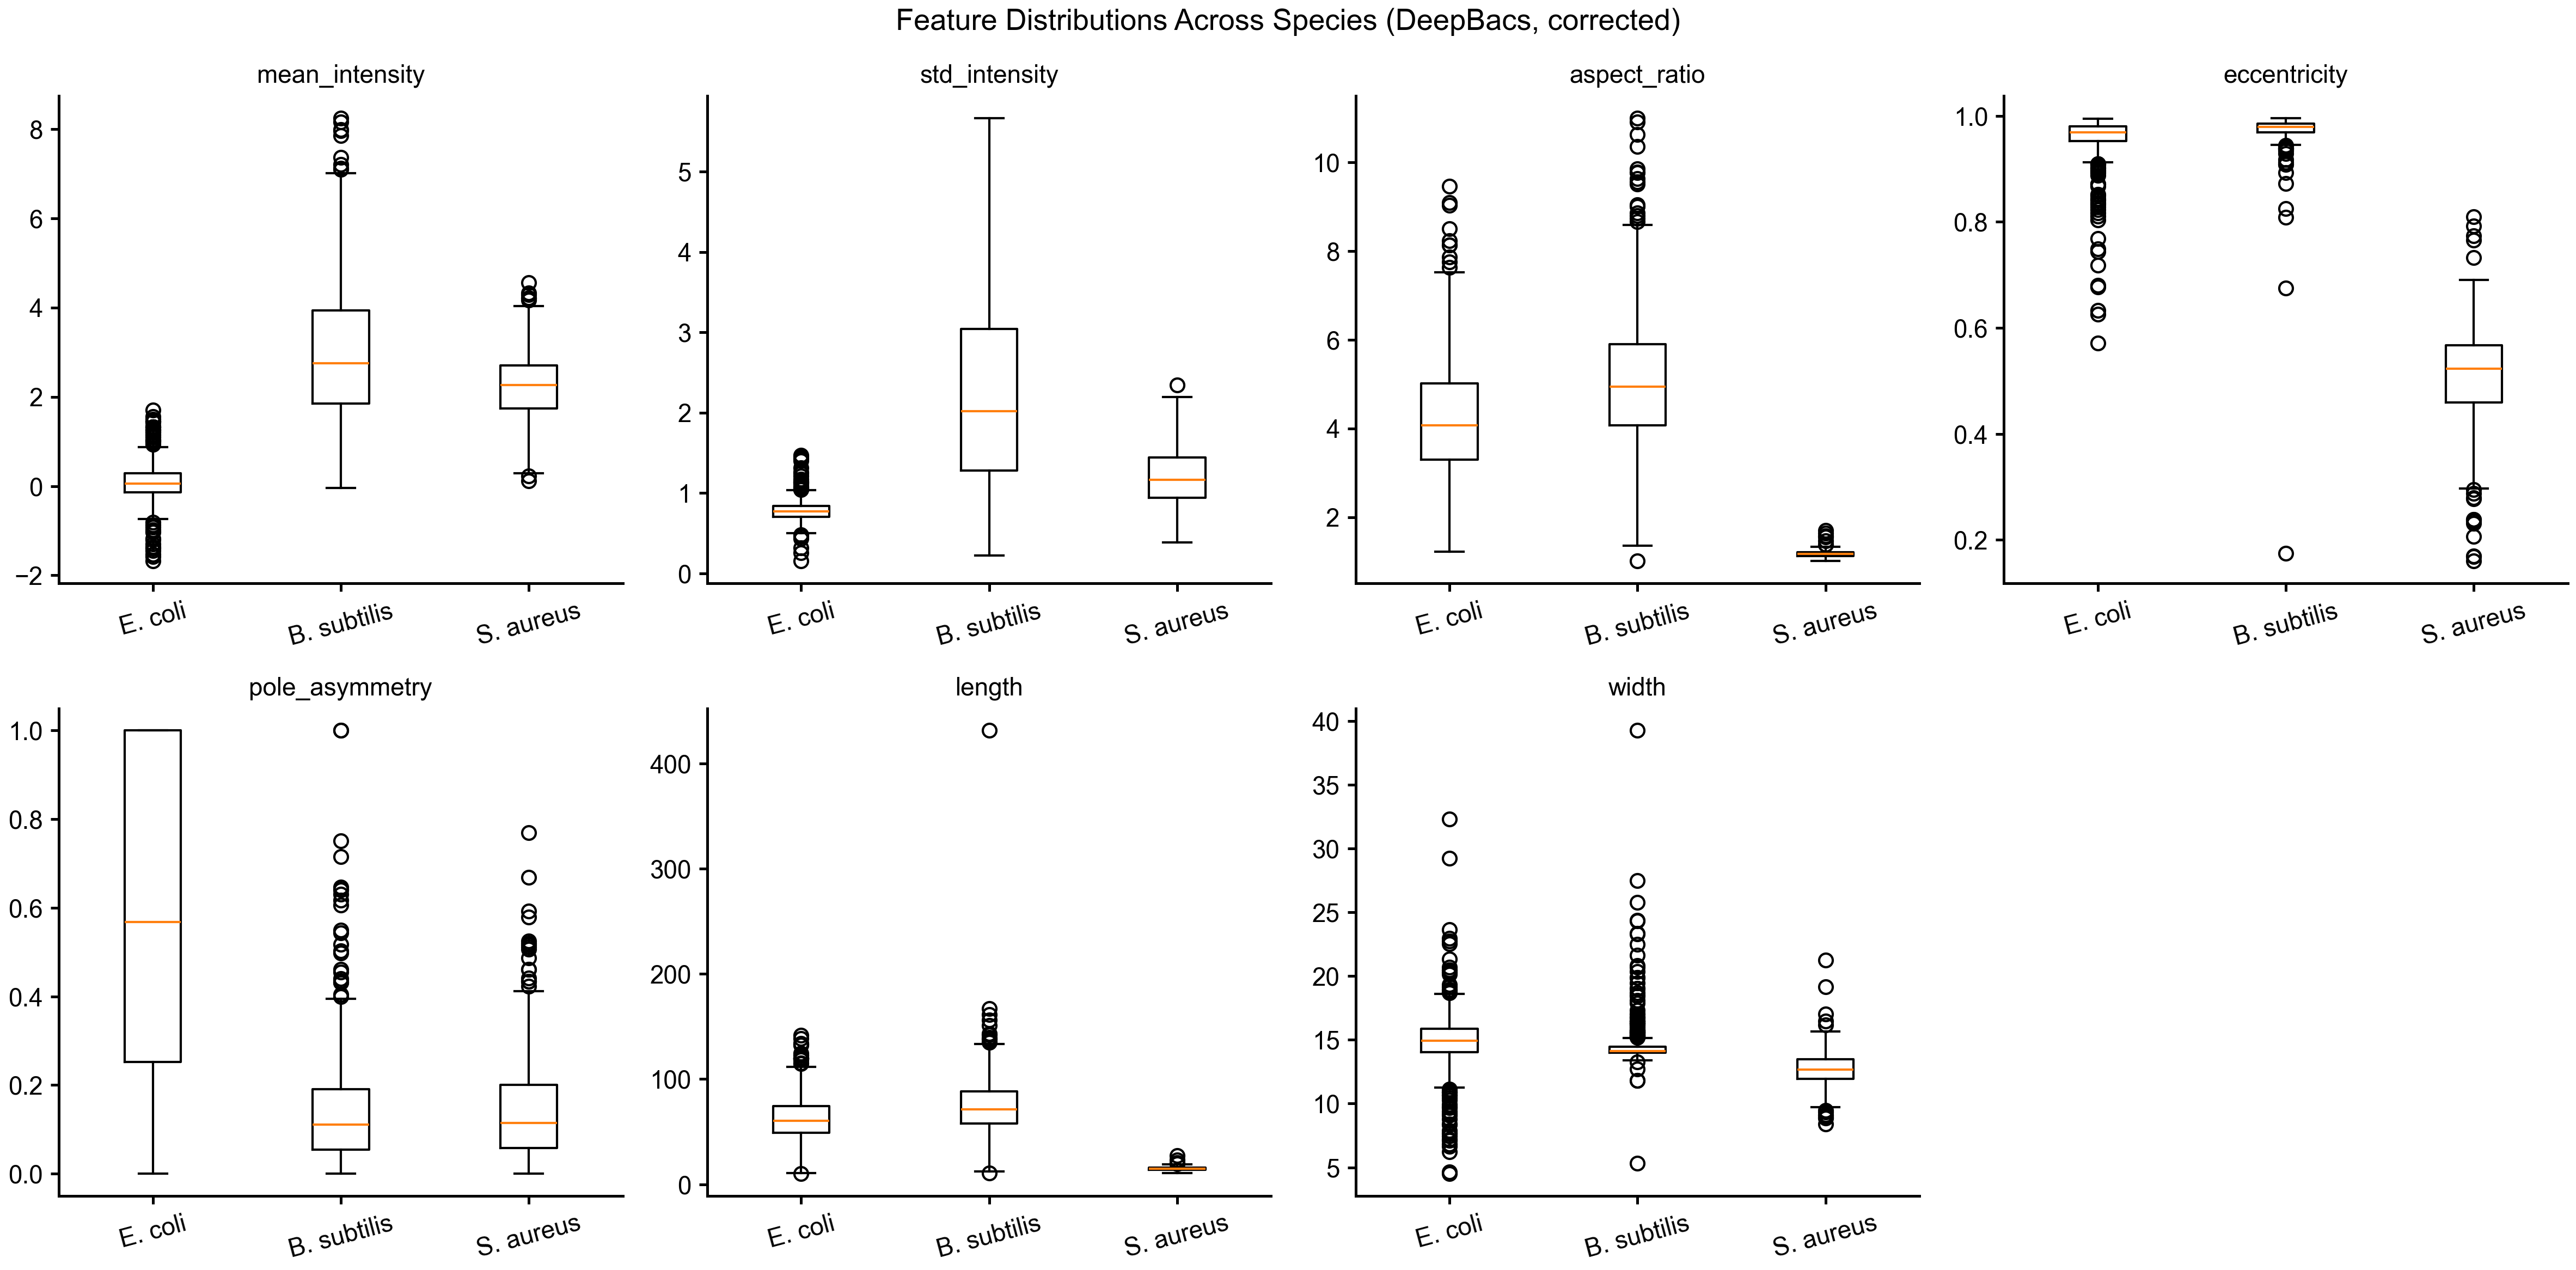

Saved corrected boxplot.


In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl

# Publication style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

combined = pd.read_csv('../data/features/deepbacs_features.csv')
print(f"Before filter: {len(combined)} cells")
print(f"B. subtilis length > 500: {(combined[(combined['species']=='bsubtilis') & (combined['length']>500)].shape[0])} cells")

combined_clean = combined[combined['length'] < 500].copy()
print(f"After filter: {len(combined_clean)} cells")
print(combined_clean.groupby('species').size())

features_to_compare = ['mean_intensity', 'std_intensity', 'aspect_ratio',
                        'eccentricity', 'pole_asymmetry', 'length', 'width']
species_list = combined_clean['species'].unique()

print("\n=== CORRECTED Kruskal-Wallis (length < 500) ===")
print(f"{'Feature':<25} {'H-stat':>8} {'p-value':>10} {'Significant':>12}")
print("-" * 60)
for feat in features_to_compare:
    groups = [combined_clean[combined_clean['species']==s][feat].dropna().values
              for s in species_list]
    groups = [g for g in groups if len(g) > 5]
    h, p = stats.kruskal(*groups)
    sig = "YES" if p < 0.05 else "no"
    print(f"{feat:<25} {h:>8.2f} {p:>10.4f} {sig:>12}")

print("\n=== CORRECTED SUMMARY MEANS ===")
print(combined_clean.groupby('species')[features_to_compare].mean().round(3).to_string())

# Corrected boxplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flat
for i, feat in enumerate(features_to_compare):
    ax = axes[i]
    data = [combined_clean[combined_clean['species']==s][feat].dropna().values
            for s in ['ecoli', 'bsubtilis', 'staph']]
    ax.boxplot(data, tick_labels=['E. coli', 'B. subtilis', 'S. aureus'])
    ax.set_title(feat, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions Across Species (DeepBacs, corrected)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/week6_crossspecies_boxplot_corrected.png', dpi=300)
plt.savefig('../outputs/figures/week6_crossspecies_boxplot_corrected.pdf', dpi=300)
plt.show()
print("Saved corrected boxplot.")

# Also save corrected data
combined_clean.to_csv('../data/features/deepbacs_features_clean.csv', index=False)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import pandas as pd, numpy as np

df = pd.read_csv('../data/features/feature_matrix_clean.csv')
FEATURE_COLS = [c for c in df.columns if c != 'divided']
X = df[FEATURE_COLS].values
y = df['divided'].values

# Three-way split: 60% train, 20% calibration, 20% test
X_tmp,   X_test,  y_tmp,   y_test  = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_cal,   y_train, y_cal   = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=42)

print(f"Train: {len(y_train)}, Calibration: {len(y_cal)}, Test: {len(y_test)}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_cal_s   = scaler.transform(X_cal)
X_test_s  = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                              random_state=42)
clf.fit(X_train_s, y_train)

# Nonconformity scores on calibration set
cal_probs     = clf.predict_proba(X_cal_s)
nonconf_scores = 1 - cal_probs[np.arange(len(y_cal)), y_cal]

print(f"\nNonconformity scores — mean: {nonconf_scores.mean():.4f}, "
      f"std: {nonconf_scores.std():.4f}")

alpha_levels = [0.05, 0.10, 0.20]
test_probs   = clf.predict_proba(X_test_s)

print("\n=== CONFORMAL PREDICTION SETS ===")
print(f"{'Alpha':>8} {'Target Cov':>12} {'Empirical Cov':>15} "
      f"{'Avg Set Size':>14} {'Empty Sets':>12} {'Both Classes':>13}")
print("-" * 80)

for alpha in alpha_levels:
    q = np.quantile(nonconf_scores, 1 - alpha)

    prediction_sets = []
    for i in range(len(y_test)):
        pred_set = []
        for cls in [0, 1]:
            score = 1 - test_probs[i, cls]
            if score <= q:
                pred_set.append(cls)
        prediction_sets.append(pred_set)

    coverage   = np.mean([y_test[i] in s for i, s in enumerate(prediction_sets)])
    avg_size   = np.mean([len(s) for s in prediction_sets])
    empty      = sum(1 for s in prediction_sets if len(s) == 0)
    both       = sum(1 for s in prediction_sets if len(s) == 2)
    target_cov = 1 - alpha

    valid = "✓" if coverage >= target_cov else "✗ INVALID"
    print(f"{alpha:>8.2f} {target_cov:>12.3f} {coverage:>15.3f} "
          f"{avg_size:>14.3f} {empty:>12d} {both:>13d}  {valid}")

print("\nCoverage valid if empirical ≥ target at each alpha.")

# Show a few example prediction sets
print("\nSample prediction sets (first 10 test points):")
print(f"{'True':>6} {'Pred Set':>12} {'Contains True?':>15}")
for i in range(10):
    pred_set = prediction_sets[i]
    contains = y_test[i] in pred_set
    label_map = {0:'Arrested', 1:'Divided'}
    set_str = str([label_map[c] for c in pred_set])
    print(f"{label_map[y_test[i]]:>8} {set_str:>30} {str(contains):>15}")

Train: 872, Calibration: 291, Test: 291

Nonconformity scores — mean: 0.2218, std: 0.2121

=== CONFORMAL PREDICTION SETS ===
   Alpha   Target Cov   Empirical Cov   Avg Set Size   Empty Sets  Both Classes
--------------------------------------------------------------------------------
    0.05        0.950           0.952          1.186            0            54  ✓
    0.10        0.900           0.924          1.065            0            19  ✓
    0.20        0.800           0.835          0.900           29             0  ✓

Coverage valid if empirical ≥ target at each alpha.

Sample prediction sets (first 10 test points):
  True     Pred Set  Contains True?
 Divided                             []           False
 Divided                    ['Divided']            True
 Divided                    ['Divided']            True
 Divided                    ['Divided']            True
Arrested                   ['Arrested']            True
Arrested                    ['Divided']         